In [1]:
import os, glob
import pandas as pd

# Get all processed discharge cycles from Week 2
files = glob.glob("../data/processed/B0005_cycle_*.csv")
cycle_nums = sorted([int(f.split("_")[-1].split(".")[0]) for f in files])

print("Available discharge cycles:", cycle_nums[:5], "...", cycle_nums[-5:])
print("Total discharge cycles:", len(cycle_nums))


Available discharge cycles: [2, 4, 6, 8, 10] ... [600, 604, 608, 612, 614]
Total discharge cycles: 168


In [3]:
# Early, mid, late discharge cycles
early = cycle_nums[0]
mid = cycle_nums[len(cycle_nums)//2]
late = cycle_nums[-1]

selected_cycles = [early, mid, late]
print("Selected cycles:", selected_cycles)


Selected cycles: [2, 294, 614]


In [4]:
def degradation_model(cycle_num, Q0=2.0, R0=0.01, kQ=1e-4, kR=5e-4):
    """
    Returns degraded capacity (Ah) and resistance (Ω) at a given cycle.
    Q decreases linearly, R increases linearly with cycles.
    """
    Q = Q0 * (1 - kQ * cycle_num)
    R = R0 * (1 + kR * cycle_num)
    return Q, R


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def thermal_simulation(current_profile, time_profile, R_internal=0.01, hA=0.1, 
                       m=0.045, Cp=900, T_amb=25):
    """
    Simulates battery temperature over time given current profile.
    """
    T = np.zeros_like(time_profile, dtype=float)
    T[0] = T_amb
    dt = np.mean(np.diff(time_profile))
    
    for t in range(1, len(time_profile)):
        Q_gen = (current_profile[t]**2) * R_internal
        Q_loss = hA * (T[t-1] - T_amb)
        dT = (Q_gen - Q_loss) * dt / (m * Cp)
        T[t] = T[t-1] + dT
    return T


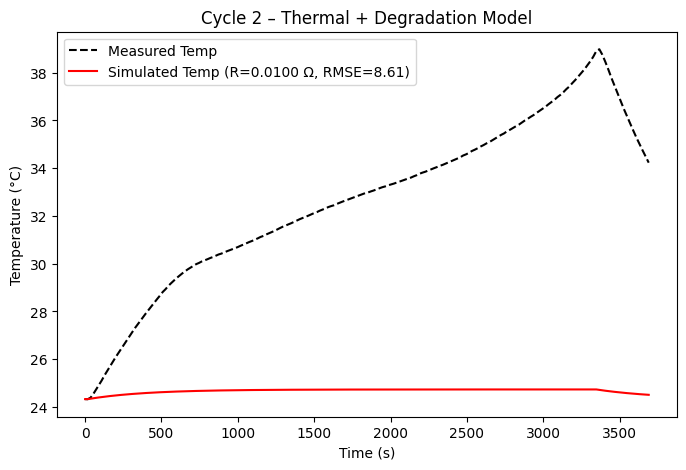

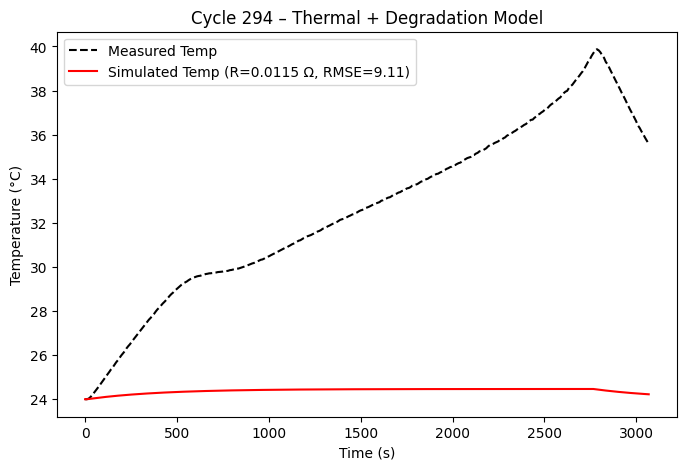

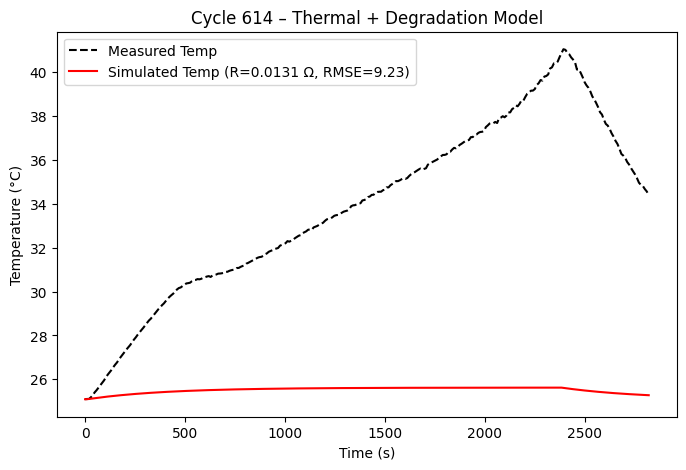

In [6]:
for c in selected_cycles:
    df = pd.read_csv(f"../data/processed/B0005_cycle_{c}.csv")
    
    time_profile = df["time_s"].values
    current_profile = df["current_A"].values
    T_meas = df["temp_C"].values
    T_amb = T_meas[0]
    
    # Apply degradation model
    Q, R = degradation_model(c)
    
    # Run thermal simulation with degraded R
    T_sim = thermal_simulation(current_profile, time_profile, 
                               R_internal=R, hA=0.1, T_amb=T_amb)
    
    # Compute error
    rmse = np.sqrt(mean_squared_error(T_meas, T_sim))
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(time_profile, T_meas, 'k--', label="Measured Temp")
    plt.plot(time_profile, T_sim, 'r-', label=f"Simulated Temp (R={R:.4f} Ω, RMSE={rmse:.2f})")
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Cycle {c} – Thermal + Degradation Model")
    plt.legend()
    plt.show()


In [7]:
# Parameters for degradation model (tune later)
Q0 = 2.0     # Initial capacity in Ah (approx. for 18650 cell)
R0 = 0.01    # Initial resistance in Ω
kQ = 1e-4    # Capacity fade rate per cycle
kR = 5e-4    # Resistance growth rate per cycle

capacity_results = []
for c in cycle_nums:
    Q, R = degradation_model(c, Q0=Q0, R0=R0, kQ=kQ, kR=kR)
    capacity_results.append({"cycle_num": c, "capacity_Ah": Q, "resistance_Ohm": R})

df_degradation = pd.DataFrame(capacity_results)


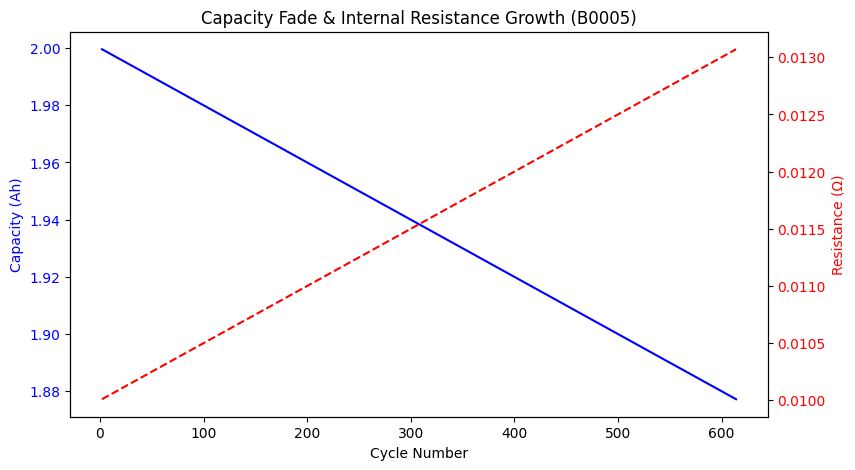

In [8]:
fig, ax1 = plt.subplots(figsize=(9,5))

# Capacity fade (left axis)
ax1.plot(df_degradation["cycle_num"], df_degradation["capacity_Ah"], 'b-', label="Capacity (Ah)")
ax1.set_xlabel("Cycle Number")
ax1.set_ylabel("Capacity (Ah)", color="b")
ax1.tick_params(axis='y', labelcolor="b")

# Resistance growth (right axis)
ax2 = ax1.twinx()
ax2.plot(df_degradation["cycle_num"], df_degradation["resistance_Ohm"], 'r--', label="Resistance (Ω)")
ax2.set_ylabel("Resistance (Ω)", color="r")
ax2.tick_params(axis='y', labelcolor="r")

plt.title("Capacity Fade & Internal Resistance Growth (B0005)")
plt.show()
